# Download các thư viện cần thiết

In [1]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tạo hàm để đọc file parquet (đọc các file parquet - data sau khi được processed)

In [2]:
def read_parquet_user(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    user_chunk_files = [file for file in files if 'user_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    user_chunk_df = pl.concat([pl.read_parquet(file) for file in user_chunk_files]) if user_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return user_chunk_df

In [3]:
def read_parquet_item(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    item_chunk_files = [file for file in files if 'item_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    item_chunk_df = pl.concat([pl.read_parquet(file) for file in item_chunk_files]) if item_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return item_chunk_df

In [4]:
def read_parquet_transaction(train_path: str):
    # Lấy tất cả các file parquet trong thư mục
    files = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.parquet')]
    
    # Phân loại các file theo loại tên
    purchase_chunk_files = [file for file in files if 'purchase_history_daily_chunk' in file]
        
    # Đọc các file riêng biệt thành DataFrame
    purchase_chunk_df = pl.concat([pl.read_parquet(file) for file in purchase_chunk_files]) if purchase_chunk_files else None
        
    # Trả về một dictionary chứa các DataFrame
    return purchase_chunk_df

# Tạo hàm lưu file parquet sau mỗi task

In [5]:
def split_and_save_parquet(df, num_files, output_dir):
    """
    Tách DataFrame thành nhiều file Parquet và lưu vào thư mục đích.
    
    :param df: DataFrame cần tách
    :param num_files: Số lượng file Parquet muốn tách
    :param output_dir: Thư mục lưu các file Parquet
    """
    # Đảm bảo thư mục tồn tại
    os.makedirs(output_dir, exist_ok=True)
    
    # Tính số dòng mỗi file sẽ có
    num_rows = df.height
    rows_per_file = num_rows // num_files

    # Tách DataFrame thành các phần và lưu mỗi phần vào một file Parquet
    for i in range(num_files):
        start_row = i * rows_per_file
        # Đảm bảo phần cuối cùng sẽ chứa tất cả các dòng còn lại
        end_row = (i + 1) * rows_per_file if i < num_files - 1 else num_rows
        
        # Tách phần DataFrame
        split_df = df[start_row:end_row]
        
        # Lưu phần DataFrame vào file .parquet
        file_path = os.path.join(output_dir, f"sale_pers.purchase_history_daily_chunk_{i}.parquet")
        split_df.write_parquet(file_path)
        print(f"Đã lưu file: {file_path}")

# Load dataset ban đầu

In [6]:
user = read_parquet_user(".././dataset")
user.head()

customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
i32,str,i32,str,str,i64,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,i64,str,str,bool
14732,"""Nam""",155,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - Grand View Phú Mỹ Hưng""","""In-Store""",1306281600,"""7""","""e1e48206652bf8c279ff0206c69a80…",false
15126,"""Nữ""",300,"""Hồ Chí Minh""","""Standard""",1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 121A Nguyễn Duy Trinh""","""In-Store""",1306281600,"""Thủ Đức""","""77891759204bd27e69fb11a7b92889…",false
29718,"""Nữ""",157,"""Bến Tre""","""Standard""",1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đồng bằng sông Cửu Long""","""BTR - 179 Nguyễn Đình Chiểu""","""In-Store""",1582070400,"""Bến Tre""","""b8041b584a0bb6655361727a0a6108…",false
30077,"""Nữ""",53,"""Hồ Chí Minh""","""Standard""",1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 101 Trần Quang Khải""","""In-Store""",1314230400,"""1""","""c52ceaca44a83ec41a219cfaff0e05…",false
30085,"""Nữ""",660,"""Hồ Chí Minh""","""Standard""",1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2,2025-07-16 11:54:29.816986,null,"""Đông Nam Bộ""","""HCM - 85-87 Tây Thạnh""","""In-Store""",1314230400,"""Tân Phú""","""74ac5764f5d67d341aacf238d7762f…",false


# Thống kê đơn biến

Hàm thống kê tần suất (frequency table) cho 1 cột

In [88]:
import polars as pl

def describe_categorical(df: pl.DataFrame, col: str):
    """
    Trả về frequency table cho 1 cột categorical.
    Gồm:
    - value
    - count
    - pct (tỷ lệ %)
    """
    counts = (
        df
        .group_by(col)
        .agg(pl.count().alias("count"))
        .with_columns(
            (pl.col("count") / pl.col("count").sum()).alias("pct")
        )
        .sort("count", descending=True)
    )
    return counts


In [89]:
categorical_cols = [
    "gender",
    "location",
    "province",
    "membership",
    "sync_status_id",
    "sync_error_message",
    "region",
    "location_name",
    "install_app",
    "district",
    "is_deleted",
]

results = {}

for col in categorical_cols:
    results[col] = describe_categorical(user, col)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1072091738.py:14: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


In [90]:
import os

# Thư mục lưu file
save_dir = "./statistics/univariate"

# Tạo folder nếu chưa tồn tại
os.makedirs(save_dir, exist_ok=True)

# Lưu từng results[col] vào file CSV
for col in categorical_cols:
    print(f"\n===== {col} =====") 
    print(results[col])
    save_path = os.path.join(save_dir, f"{col}_univariate.csv")
    results[col].write_csv(save_path)
    print(f"Saved: {save_path}")



===== gender =====
shape: (3, 3)
┌────────┬─────────┬──────────┐
│ gender ┆ count   ┆ pct      │
│ ---    ┆ ---     ┆ ---      │
│ str    ┆ u32     ┆ f64      │
╞════════╪═════════╪══════════╡
│ Nữ     ┆ 3424887 ┆ 0.748779 │
│ Nam    ┆ 1149069 ┆ 0.25122  │
│ Khác   ┆ 8       ┆ 0.000002 │
└────────┴─────────┴──────────┘
Saved: ./statistics/univariate\gender_univariate.csv

===== location =====
shape: (995, 3)
┌──────────┬───────┬───────────┐
│ location ┆ count ┆ pct       │
│ ---      ┆ ---   ┆ ---       │
│ i32      ┆ u32   ┆ f64       │
╞══════════╪═══════╪═══════════╡
│ 766      ┆ 22383 ┆ 0.004894  │
│ 455      ┆ 21746 ┆ 0.004754  │
│ 598      ┆ 21509 ┆ 0.004702  │
│ 264      ┆ 20835 ┆ 0.004555  │
│ 687      ┆ 20563 ┆ 0.004496  │
│ …        ┆ …     ┆ …         │
│ 479      ┆ 40    ┆ 0.000009  │
│ 809      ┆ 17    ┆ 0.000004  │
│ 826      ┆ 5     ┆ 0.000001  │
│ 491      ┆ 1     ┆ 2.1863e-7 │
│ 869      ┆ 1     ┆ 2.1863e-7 │
└──────────┴───────┴───────────┘
Saved: ./statistics/univar

In [80]:
import polars as pl

def count_null_and_empty(df: pl.DataFrame, col: str):
    s = df[col]

    null_count = s.is_null().sum()
    empty_count = (
        s.cast(pl.Utf8)
         .str.strip_chars()
         .eq("")
         .sum()
    )
    return null_count, empty_count

cols_to_check = [
    "district",
    "province",
    "gender",
    "membership",
    "location",
    "install_app",
    "location_name",
]

for col in cols_to_check:
    null_c, empty_c = count_null_and_empty(user, col)
    print(f"{col}: null = {null_c}, empty = {empty_c}")

district: null = 0, empty = 0
province: null = 0, empty = 0
gender: null = 0, empty = 0
membership: null = 0, empty = 0
location: null = 0, empty = 0
install_app: null = 0, empty = 0
location_name: null = 0, empty = 0


# Trực quan hoá đơn biến

In [93]:
import os

save_dir = "./visualize/univariate"
os.makedirs(save_dir, exist_ok=True)

In [94]:
categorical_cols = [
    "gender",
    "location",
    "province",
    "membership",
    "region",
    "location_name",
    "install_app",
    "district",
]

In [95]:
def plot_pie(df_pl, col, top_k=10, save_path=None):
    df = df_pl.to_pandas()

    if len(df) > top_k:
        df_top = df.head(top_k)
        others_pct = df["pct"][top_k:].sum()
        others_count = df["count"][top_k:].sum()

        others_row = pd.DataFrame({
            col: ["Others"],
            "count": [others_count],
            "pct": [others_pct]
        })

        df_plot = pd.concat([df_top, others_row], ignore_index=True)
    else:
        df_plot = df

    plt.figure(figsize=(6, 6))
    plt.pie(
        df_plot["pct"],
        labels=df_plot[col],
        autopct="%1.1f%%",
        startangle=90,
    )
    plt.title(f"Distribution of {col}")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

Saving pie chart for region → ./visualize/univariate\region_pie.png


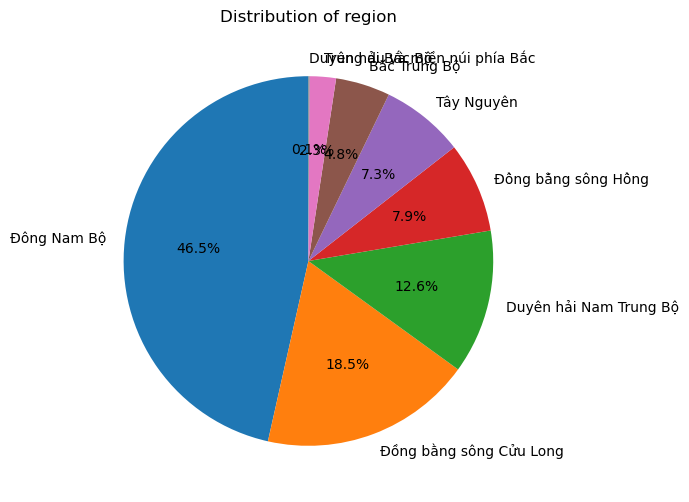

In [96]:
pie_cols = ["region"]

for col in pie_cols:
    save_path = os.path.join(save_dir, f"{col}_pie.png")
    print(f"Saving pie chart for {col} → {save_path}")
    plot_pie(results[col], col, save_path=save_path)

In [98]:
def plot_bar_colorful(df_pl, col, top_k=None, save_path=None):
    df = df_pl.to_pandas()

    if top_k is not None:
        df = df.head(top_k)

    if "pct" in df.columns:
        df = df.sort_values("pct", ascending=False)

    n = len(df)
    colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))

    figsize = (12, 5) if col in ("gender", "membership", "install_app") else (30, 5)

    plt.figure(figsize=figsize)
    plt.bar(df[col].astype(str), df["pct"], color=colors)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

Saving bar chart for gender → ./visualize/univariate\gender_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


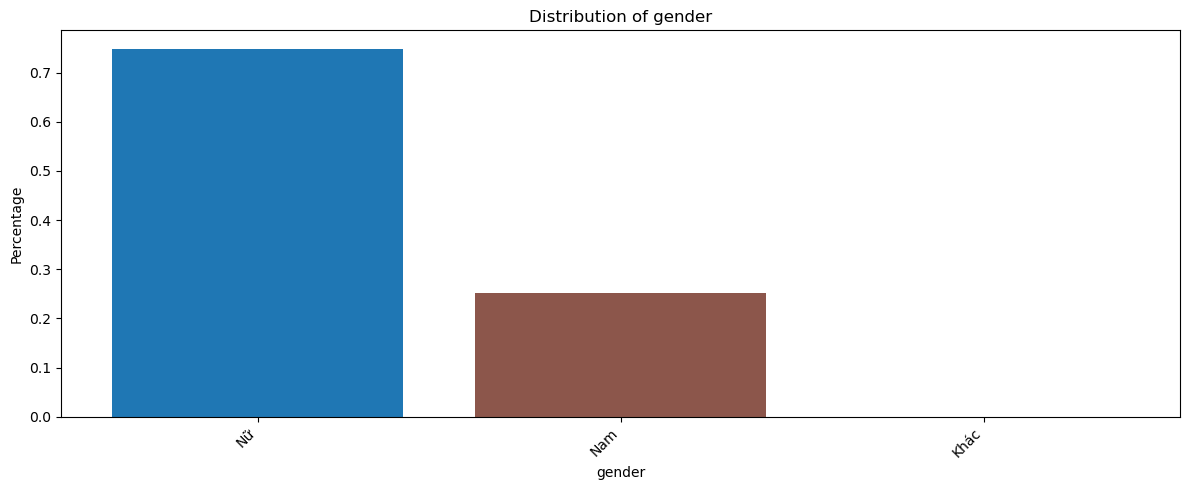

Saving bar chart for membership → ./visualize/univariate\membership_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


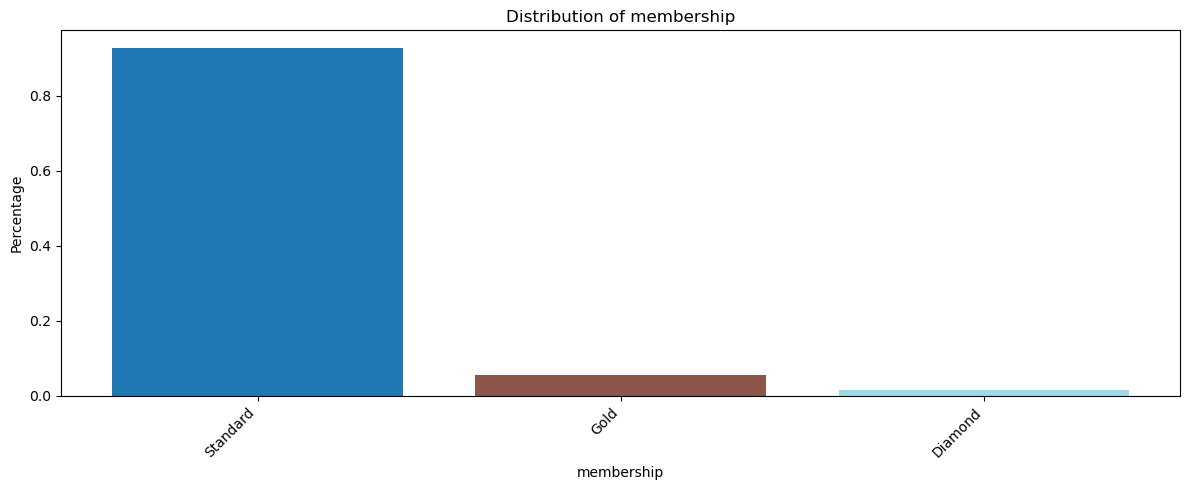

Saving bar chart for install_app → ./visualize/univariate\install_app_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


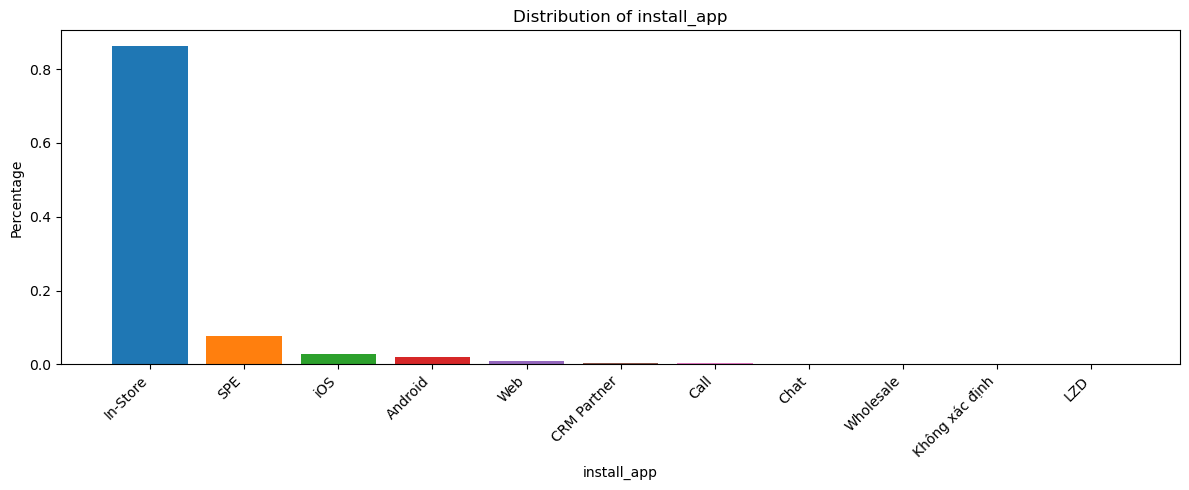

In [99]:
bar_cols = ["gender", "membership", "install_app"]

for col in bar_cols:
    save_path = os.path.join(save_dir, f"{col}_bar.png")
    print(f"Saving bar chart for {col} → {save_path}")
    plot_bar_colorful(results[col], col, save_path=save_path)

Saving bar chart for district → ./visualize/univariate\district_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


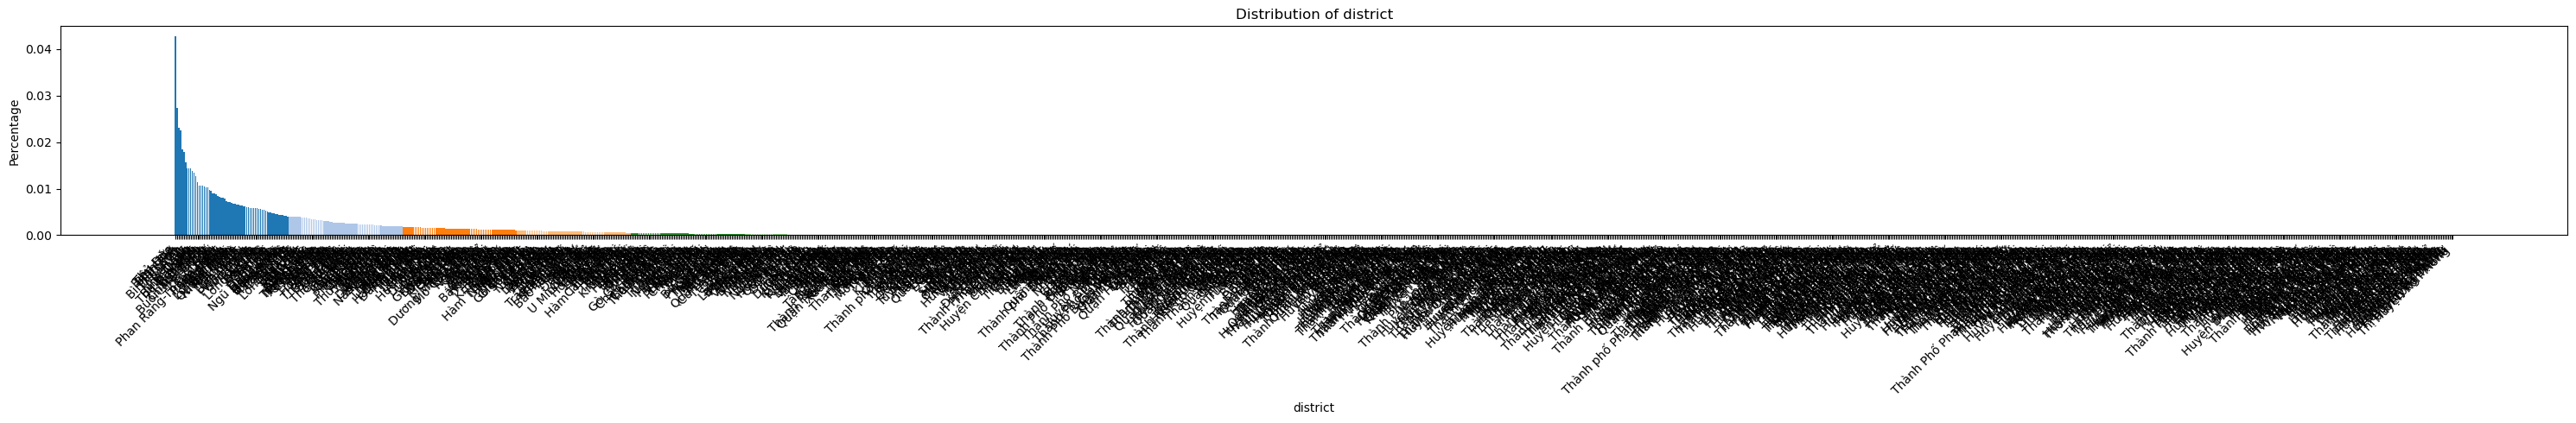

Saving bar chart for province → ./visualize/univariate\province_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


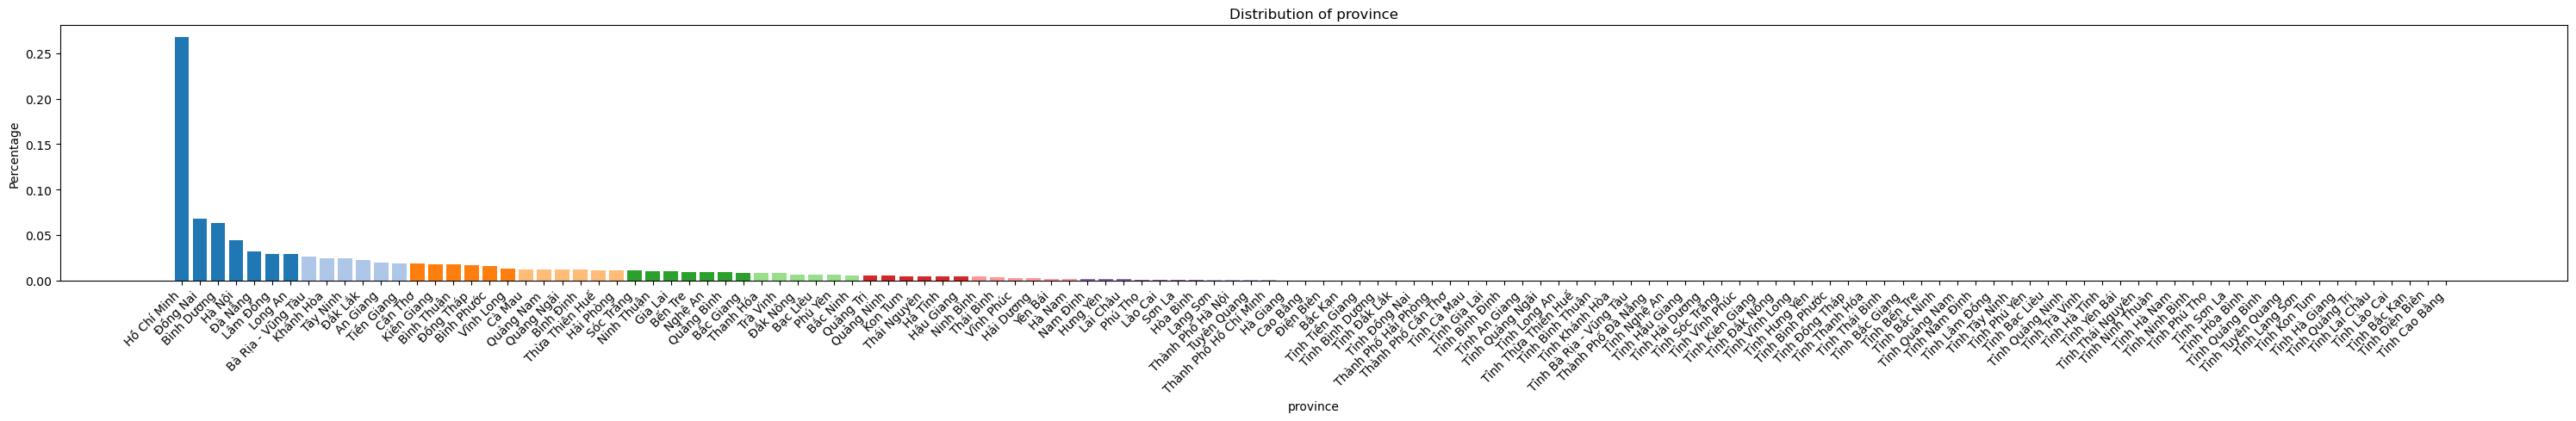

Saving bar chart for location → ./visualize/univariate\location_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


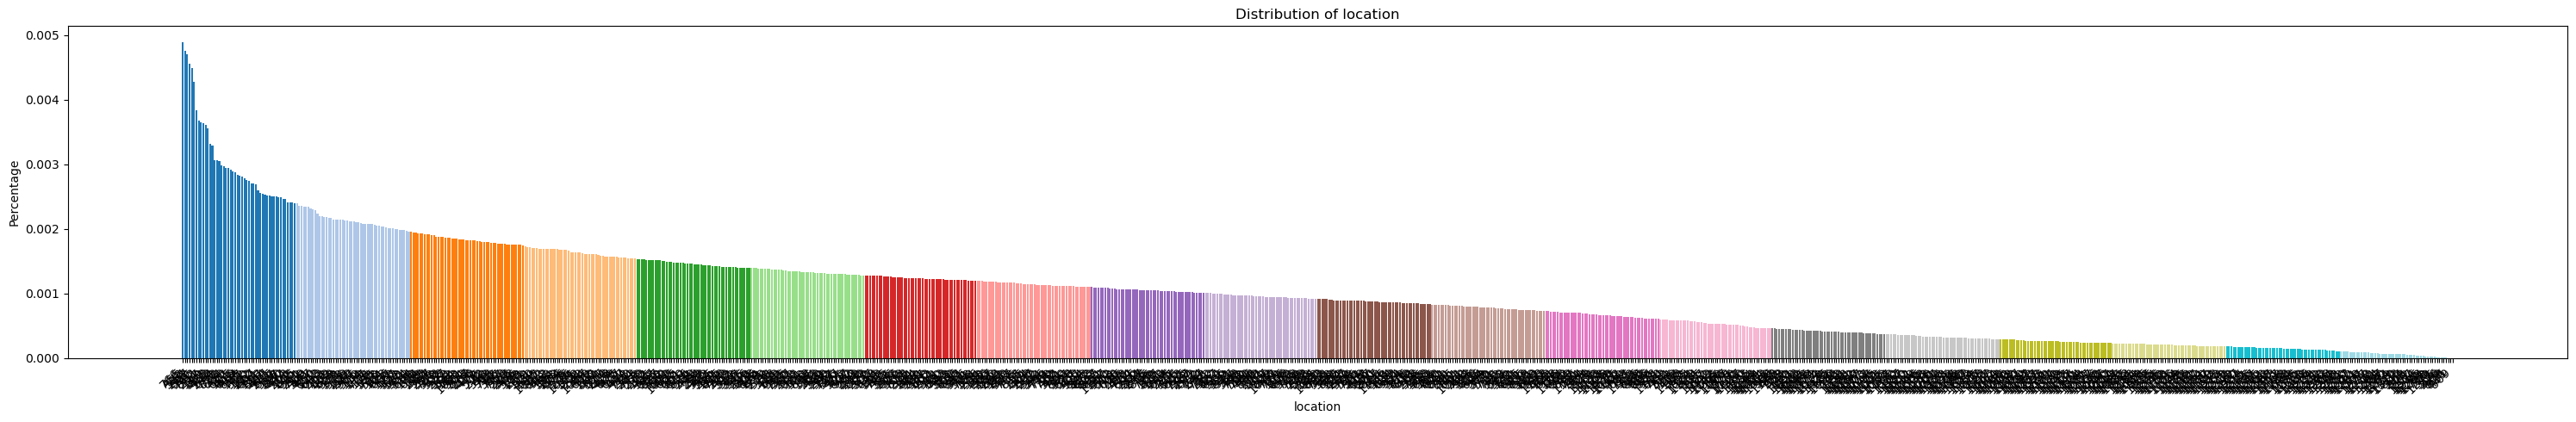

Saving bar chart for location_name → ./visualize/univariate\location_name_bar.png


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1653293379.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20")(np.linspace(0, 1, n))


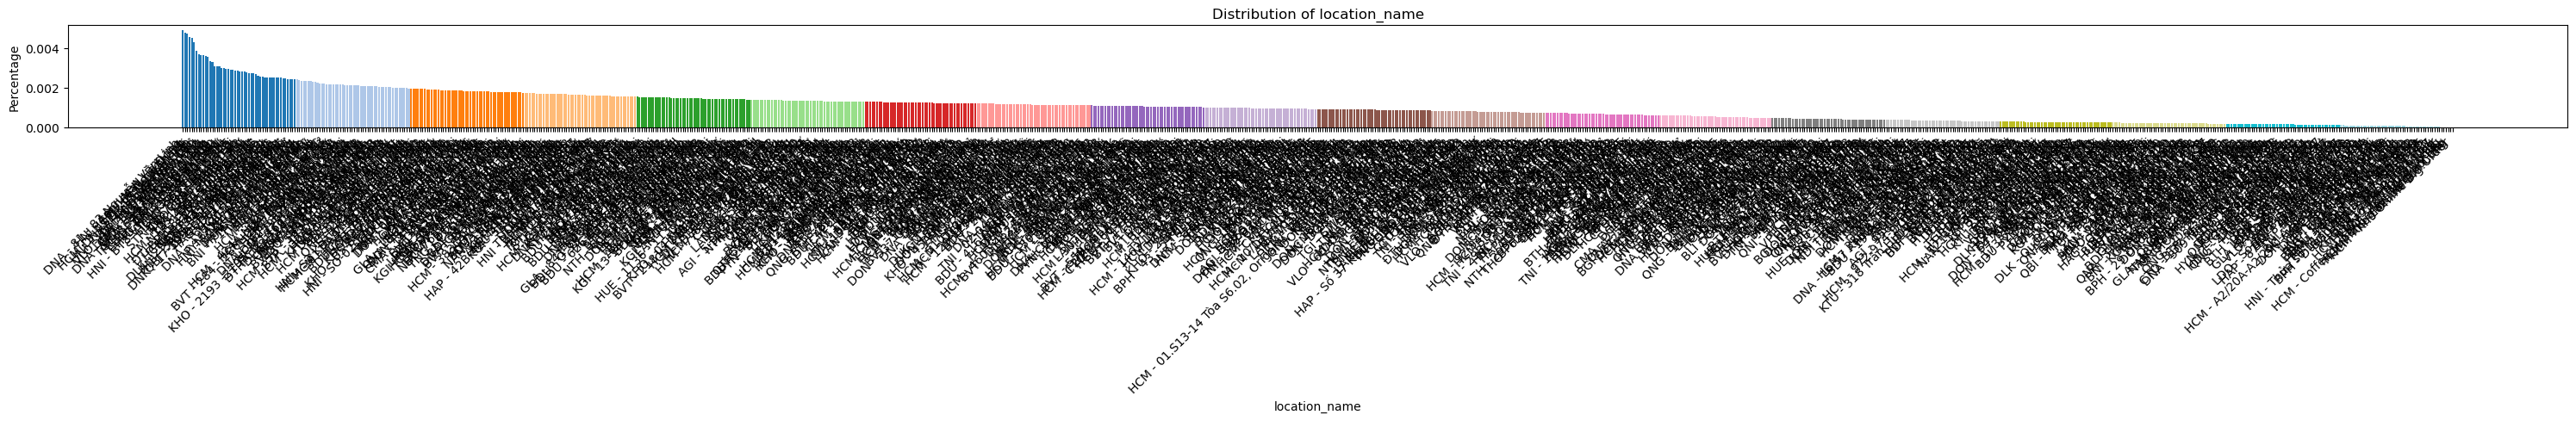

In [100]:
bar_cols = ["district", "province", "location", "location_name"]

for col in bar_cols:
    save_path = os.path.join(save_dir, f"{col}_bar.png")
    print(f"Saving bar chart for {col} → {save_path}")
    plot_bar_colorful(results[col], col, save_path=save_path)

# Kiểm tra sự bất thường của dữ liệu (đơn biến)

Danh sách cột cần kiểm tra. Lí do kiểm tra là phân bố dữ liệu khá chi chít nhau

In [68]:
cols_to_check = [
    "district",
    "province",
    "location",
    "location_name",
]

Kiểm tra giá trị bất thường cho từng cột:
- Categorical trùng nghĩa
- Rare Categorical

In [67]:
import polars as pl
import re

def normalize_text(s: str):
    if s is None:
        return None
    s = s.lower()
    s = s.strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s\-]", "", s)
    return s

def check_categorical_anomalies(df: pl.DataFrame, col: str, top_k=50):
    print(f"\n================= {col} =================")

    # 1. Null / empty
    null_count = df[col].is_null().sum()
    empty_count = (df[col].cast(pl.Utf8).str.strip_chars() == "").sum()
    print(f"Null values: {null_count}")
    print(f"Empty string values: {empty_count}")

    # 2. Raw frequency
    raw_freq = (
        df
        .group_by(col)
        .agg(pl.count().alias("count"))
        .sort("count", descending=True)
        .head(top_k)
    )
    print("\n--- Top raw categories (trước chuẩn hoá) ---")
    print(raw_freq)

    # 3. Normalize text → dùng map_elements (không dùng apply)
    df_norm = df.with_columns(
        pl.col(col)
        .cast(pl.Utf8)
        .map_elements(normalize_text, return_dtype=pl.Utf8)
        .alias(f"{col}_norm")
    )

    # 4. Normalized frequency
    norm_freq = (
        df_norm
        .group_by(f"{col}_norm")
        .agg(pl.count().alias("count"))
        .sort("count", descending=True)
        .head(top_k)
    )
    print("\n--- Top normalized categories (sau chuẩn hoá) ---")
    print(norm_freq)

    # 5. Mapping raw → normalized (để phát hiện trùng nghĩa)
    mapping = (
        df_norm
        .group_by([col, f"{col}_norm"])
        .agg(pl.count().alias("count"))
        .sort(f"{col}_norm")
    )
    print("\n--- Mapping raw → normalized ---")
    print(mapping)

    # 6. Rare categories < 1%
    total = len(df)
    rare = mapping.filter(pl.col("count") < 0.01 * total)
    print("\n--- Rare categories (<1%) ---")
    print(rare)

In [69]:
for col in cols_to_check:
    check_categorical_anomalies(user, col)


================= district =================
Null values: 0
Empty string values: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1479865081.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))



--- Top raw categories (trước chuẩn hoá) ---
shape: (50, 2)
┌────────────┬────────┐
│ district   ┆ count  │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ Thủ Đức    ┆ 195601 │
│ Biên Hòa   ┆ 125390 │
│ Bình Tân   ┆ 105858 │
│ Tân Phú    ┆ 102835 │
│ Bình Chánh ┆ 84427  │
│ …          ┆ …      │
│ Phú Nhuận  ┆ 26820  │
│ Sóc Trăng  ┆ 26695  │
│ 6          ┆ 26583  │
│ Trà Vinh   ┆ 26380  │
│ 3          ┆ 26097  │
└────────────┴────────┘


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1479865081.py:45: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))



--- Top normalized categories (sau chuẩn hoá) ---
shape: (50, 2)
┌───────────────┬────────┐
│ district_norm ┆ count  │
│ ---           ┆ ---    │
│ str           ┆ u32    │
╞═══════════════╪════════╡
│ thủ đức       ┆ 195601 │
│ biên hòa      ┆ 125390 │
│ bình tân      ┆ 105858 │
│ tân phú       ┆ 102835 │
│ bình chánh    ┆ 84427  │
│ …             ┆ …      │
│ phú nhuận     ┆ 26820  │
│ sóc trăng     ┆ 26695  │
│ 6             ┆ 26583  │
│ trà vinh      ┆ 26380  │
│ 3             ┆ 26097  │
└───────────────┴────────┘


...


--- Top raw categories (trước chuẩn hoá) ---
shape: (50, 2)
┌───────────────────────────────┬───────┐
│ location_name                 ┆ count │
│ ---                           ┆ ---   │
│ str                           ┆ u32   │
╞═══════════════════════════════╪═══════╡
│ DNA - 81 - 83 Nguyễn Văn Linh ┆ 22383 │
│ HNI - Aeon Mall Hà Đông       ┆ 21746 │
│ HCM - 66 Nguyễn Du            ┆ 21509 │
│ HNI - 933 La Thành            ┆ 20835 │
│ HCM - 9 – 11 – 13 Nguyễn Trãi ┆ 20563 │
│ …                             ┆ …     │
│ QBI - 1 Lý Thường Kiệt        ┆ 11253 │
│ HAG - 361 Trần Hưng Đạo       ┆ 11028 │
│ TVI - 12 Điện Biên Phủ        ┆ 11014 │
│ HUE - 1 Bà Triệu              ┆ 10994 │
│ HCM - 391 Lý Thái Tổ          ┆ 10987 │
└───────────────────────────────┴───────┘


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1479865081.py:45: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))



--- Top normalized categories (sau chuẩn hoá) ---
shape: (50, 2)
┌───────────────────────────────┬───────┐
│ location_name_norm            ┆ count │
│ ---                           ┆ ---   │
│ str                           ┆ u32   │
╞═══════════════════════════════╪═══════╡
│ dna - 81 - 83 nguyễn văn linh ┆ 22383 │
│ hni - aeon mall hà đông       ┆ 21746 │
│ hcm - 66 nguyễn du            ┆ 21509 │
│ hni - 933 la thành            ┆ 20835 │
│ hcm - 9  11  13 nguyễn trãi   ┆ 20563 │
│ …                             ┆ …     │
│ qbi - 1 lý thường kiệt        ┆ 11253 │
│ hag - 361 trần hưng đạo       ┆ 11028 │
│ tvi - 12 điện biên phủ        ┆ 11014 │
│ hue - 1 bà triệu              ┆ 10994 │
│ hcm - 391 lý thái tổ          ┆ 10987 │
└───────────────────────────────┴───────┘


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\1479865081.py:56: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))



--- Mapping raw → normalized ---
shape: (995, 3)
┌────────────────────────────┬────────────────────────────┬───────┐
│ location_name              ┆ location_name_norm         ┆ count │
│ ---                        ┆ ---                        ┆ ---   │
│ str                        ┆ str                        ┆ u32   │
╞════════════════════════════╪════════════════════════════╪═══════╡
│ AGI - 110 Quốc Lộ 91       ┆ agi - 110 quốc lộ 91       ┆ 2991  │
│ AGI - 110 Tôn Đức Thắng    ┆ agi - 110 tôn đức thắng    ┆ 7038  │
│ AGI - 112 Nguyễn Văn Thoại ┆ agi - 112 nguyễn văn thoại ┆ 5807  │
│ AGI - 126 Trần Phú         ┆ agi - 126 trần phú         ┆ 4942  │
│ AGI - 200 Tỉnh Lộ 942      ┆ agi - 200 tỉnh lộ 942      ┆ 5866  │
│ …                          ┆ …                          ┆ …     │
│ ĐTH - K28 TL848            ┆ đth - k28 tl848            ┆ 3251  │
│ ĐTH - QL30                 ┆ đth - ql30                 ┆ 3441  │
│ ĐTH - QL80 Khóm 1          ┆ đth - ql80 khóm 1          ┆ 4248  

Sau khi xem biểu đồ trực quan hoá của province, nhận thấy có một vài tỉnh/thành phố bị thừa tiền tố tỉnh/thành phố.

In [74]:
import polars as pl
import re

def normalize_text_basic(s: str):
    if s is None:
        return None
    s = s.strip()
    return s

def find_province_prefix_anomalies(df: pl.DataFrame, col: str = "province"):
    """
    Tìm các trường hợp cùng 1 tỉnh/thành nhưng có nhiều biến thể tên
    do tiền tố như 'Tỉnh', 'Thành phố', 'TP', ...
    """
    print(f"\n===== Kiểm tra bất thường tiền tố cho cột: {col} =====")

    # 1. Lấy cột province, bỏ null / rỗng
    df_clean = (
        df
        .select(pl.col(col).cast(pl.Utf8).alias("province"))
        .with_columns(
            pl.col("province")
            .map_elements(normalize_text_basic, return_dtype=pl.Utf8)
            .alias("province")
        )
        .filter(
            pl.col("province").is_not_null()
            & (pl.col("province").str.strip_chars() != "")
        )
    )

    # 2. Tạo cột province_core: bỏ tiền tố
    df_core = (
        df_clean
        .with_columns(
            pl.col("province")
            .str.to_lowercase()
            .str.strip_chars()
            # bỏ các prefix: tỉnh, tinh, thành phố, thanh pho, tp, tp.
            .str.replace(r"^(tinh|tỉnh|tp\.?|tp|thanh pho|thành phố)\s+", "")
            .alias("province_core")
        )
    )

    # 3. Bảng mapping raw ↔ core
    mapping = (
        df_core
        .group_by(["province", "province_core"])
        .agg(pl.count().alias("count"))
        .sort(["province_core", "count"], descending=[False, True])
    )

    # 4. Tìm các core có nhiều hơn 1 biến thể tên
    core_stats = (
        mapping
        .group_by("province_core")
        .agg(
            pl.n_unique("province").alias("n_variants"),
            pl.col("count").sum().alias("total_count"),
        )
        .filter(pl.col("n_variants") > 1)
        .sort("total_count", descending=True)
    )

    if core_stats.height == 0:
        print("→ Không phát hiện trường hợp nào có nhiều biến thể tên (theo quy tắc prefix hiện tại).")
        return

    print("\n--- Các 'province_core' có nhiều biến thể tên ---")
    print(core_stats)

    # 5. In chi tiết từng core bất thường
    cores = core_stats["province_core"].to_list()

    print("\n--- Chi tiết từng trường hợp bất thường ---")
    for core in cores:
        sub = mapping.filter(pl.col("province_core") == core)
        print(f"\n>>> Core = '{core}'")
        print(sub)

In [75]:
find_province_prefix_anomalies(user, col="province")


===== Kiểm tra bất thường tiền tố cho cột: province =====


C:\Users\Admin\AppData\Local\Temp\ipykernel_19296\2030494651.py:49: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))



--- Các 'province_core' có nhiều biến thể tên ---
shape: (63, 3)
┌───────────────┬────────────┬─────────────┐
│ province_core ┆ n_variants ┆ total_count │
│ ---           ┆ ---        ┆ ---         │
│ str           ┆ u32        ┆ u32         │
╞═══════════════╪════════════╪═════════════╡
│ hồ chí minh   ┆ 2          ┆ 1224319     │
│ đồng nai      ┆ 2          ┆ 312380      │
│ bình dương    ┆ 2          ┆ 287857      │
│ hà nội        ┆ 2          ┆ 202879      │
│ đà nẵng       ┆ 2          ┆ 146700      │
│ …             ┆ …          ┆ …           │
│ tuyên quang   ┆ 2          ┆ 1285        │
│ hà giang      ┆ 2          ┆ 709         │
│ cao bằng      ┆ 2          ┆ 638         │
│ điện biên     ┆ 2          ┆ 610         │
│ bắc kạn       ┆ 2          ┆ 506         │
└───────────────┴────────────┴─────────────┘

--- Chi tiết từng trường hợp bất thường ---

>>> Core = 'hồ chí minh'
shape: (2, 3)
┌───────────────────────┬───────────────┬─────────┐
│ province              ┆ provin

# Thống kê đa biến

In [82]:
user=read_parquet_user(".././dataset")

In [85]:
import polars as pl
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Các cột categorical
categorical_cols = [
    "gender",
    "location",
    "province",
    "membership",
    "region",
    "location_name",
    "install_app",
    "district",
]

# 1. Chuyển subset sang pandas để xài scipy
cat_df = user.select(categorical_cols).to_pandas()

# 2. Hàm tính Cramér’s V
def cramers_v(x, y):
    """
    Tính Cramér's V giữa 2 biến phân loại (Series).
    Trả về giá trị từ 0 đến 1.
    """
    # Bảng tần suất
    confusion_matrix = pd.crosstab(x, y)

    # Nếu 1 trong 2 biến chỉ có 1 giá trị -> không tính được, trả về NaN
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# 3. Tạo ma trận n x n
n = len(categorical_cols)
cramer_matrix = pd.DataFrame(
    data=np.zeros((n, n), dtype=float),
    index=categorical_cols,
    columns=categorical_cols,
)

# 4. Điền giá trị Cramér’s V cho từng cặp
for i, col_i in enumerate(categorical_cols):
    for j, col_j in enumerate(categorical_cols):
        if i == j:
            cramer_matrix.loc[col_i, col_j] = 1.0  # tương quan với chính nó
        elif i < j:
            v = cramers_v(cat_df[col_i], cat_df[col_j])
            cramer_matrix.loc[col_i, col_j] = v
            cramer_matrix.loc[col_j, col_i] = v  # đối xứng

# 5. Lưu ma trận ra CSV
output_path = "./statistics/variate/user_categorical_cramers_v_matrix.csv"
cramer_matrix.to_csv(output_path)

print(f"Đã lưu ma trận Cramér’s V n x n xuống file: {output_path}")

Đã lưu ma trận Cramér’s V n x n xuống file: ./statistics/variate/user_categorical_cramers_v_matrix.csv


# Trực quan hoá đa biến

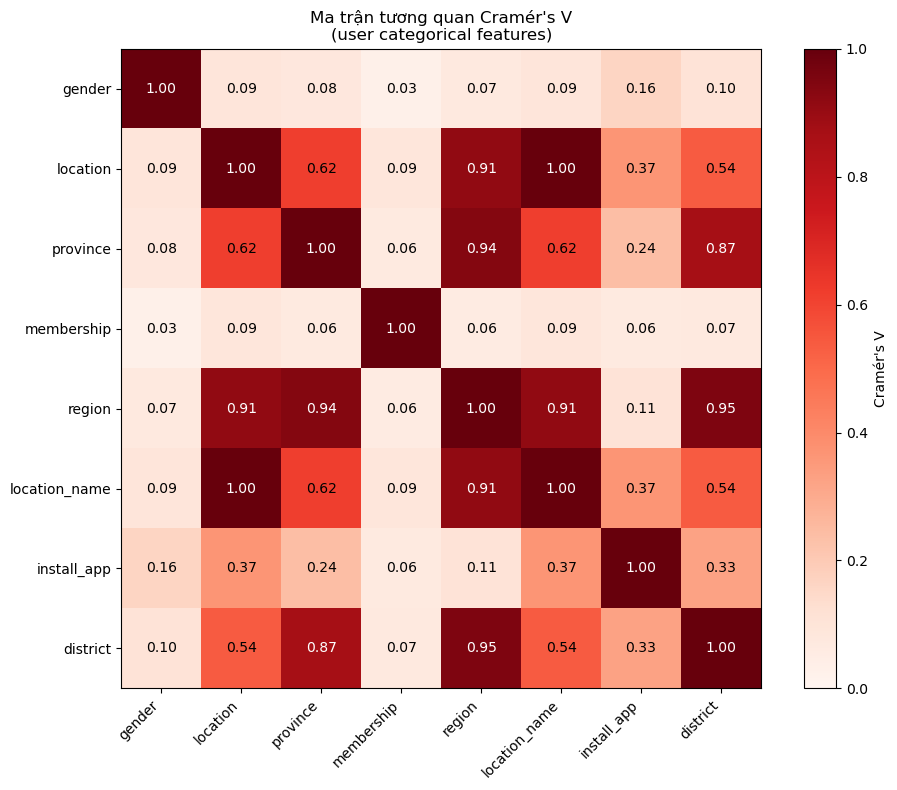

Đã lưu heatmap tại: ./statistics/variate/user_categorical_cramers_v_heatmap.png


In [87]:
import matplotlib.pyplot as plt
import numpy as np

matrix = cramer_matrix.values
labels = categorical_cols

plt.figure(figsize=(10, 8))

# Heatmap màu ĐỎ (Reds colormap)
im = plt.imshow(matrix, cmap="Reds", vmin=0, vmax=1)

# Colorbar
plt.colorbar(im, label="Cramér's V")

# Ticks & labels
plt.xticks(
    ticks=np.arange(len(labels)),
    labels=labels,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(labels)),
    labels=labels
)

# Hiển thị số trên từng ô
for i in range(len(labels)):
    for j in range(len(labels)):
        value = matrix[i, j]
        plt.text(
            j, i,
            f"{value:.2f}",               # hiển thị với 2 chữ số thập phân
            ha="center",
            va="center",
            color="black" if value < 0.7 else "white"  # đổi màu chữ để dễ nhìn
        )

plt.title("Ma trận tương quan Cramér's V\n(user categorical features)")
plt.tight_layout()

# Lưu hình
output_img_path = "./visualize/variate/user_categorical_cramers_v_heatmap.png"
plt.savefig(output_img_path, dpi=300)

# Hiển thị
plt.show()

print("Đã lưu heatmap tại:", output_img_path)